
# Session 32: Logistic Regression Classification

## Section 8 GitHub Deliverable

This notebook implements the interpretable Logistic Regression baseline for
student at-risk classification.

Target definition:

- `1` = at-risk student (`G3 < 10`)
- `0` = successful student (`G3 >= 10`)

The positive class is at risk, so recall measures the percentage of actual
at-risk students identified by the model.


## 1. Imports and repository configuration

In [1]:

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

REPO_ROOT = Path.cwd().resolve()
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
RAW_DIR = REPO_ROOT / "data" / "raw"

print("Repository root:")
print(REPO_ROOT)


Repository root:
C:\Users\nejat\OneDrive\Desktop\UN\Skills\GitHub 2026\student-performance-prediction-ml


## 2. Load the full-information dataset

In [2]:

def read_table(path):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path, sep=None, engine="python")
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix in {".pkl", ".pickle"}:
        return pd.read_pickle(path)
    raise ValueError(f"Unsupported data file: {path}")


def first_existing(paths):
    return next((Path(path) for path in paths if Path(path).exists()), None)


x_path = first_existing([
    PROCESSED_DIR / "X_full.parquet",
    PROCESSED_DIR / "X_full.csv",
    PROCESSED_DIR / "X_full.pkl",
    PROCESSED_DIR / "X_full.pickle",
])

y_path = first_existing([
    PROCESSED_DIR / "y_full.parquet",
    PROCESSED_DIR / "y_full.csv",
    PROCESSED_DIR / "y_full.pkl",
    PROCESSED_DIR / "y_full.pickle",
])

if x_path is not None and y_path is not None:
    X_full = read_table(x_path)
    y_loaded = read_table(y_path)
    if isinstance(y_loaded, pd.DataFrame):
        if "G3" in y_loaded.columns:
            y = y_loaded["G3"].copy()
        elif y_loaded.shape[1] == 1:
            y = y_loaded.iloc[:, 0].copy()
        else:
            raise ValueError("The target file must contain one column or G3.")
    else:
        y = pd.Series(y_loaded)
    data_source = f"{x_path.relative_to(REPO_ROOT)} and {y_path.relative_to(REPO_ROOT)}"
else:
    candidate_files = []
    for directory in [PROCESSED_DIR, RAW_DIR, REPO_ROOT / "data"]:
        if directory.exists():
            for pattern in ["*.csv", "*.parquet", "*.pkl", "*.pickle"]:
                candidate_files.extend(directory.rglob(pattern))

    excluded = {"classification", "leaderboard", "metric", "result", "coefficient", "prediction"}
    selected = None
    selected_path = None
    for candidate in sorted(set(candidate_files)):
        if any(term in candidate.name.lower() for term in excluded):
            continue
        try:
            frame = read_table(candidate)
        except Exception:
            continue
        if isinstance(frame, pd.DataFrame) and "G3" in frame.columns and frame.shape[0] >= 20:
            selected = frame
            selected_path = candidate
            break

    if selected is None:
        raise FileNotFoundError(
            "No usable dataset was found. Expected X_full/y_full files or a dataset containing G3."
        )

    y = selected["G3"].copy()
    X_full = selected.drop(columns=["G3"]).copy()
    data_source = str(selected_path.relative_to(REPO_ROOT))

X_full = pd.DataFrame(X_full).copy()
X_full = X_full.drop(
    columns=[column for column in X_full.columns if str(column).startswith("Unnamed:")],
    errors="ignore",
)
X_full = X_full.drop(columns=["G3"], errors="ignore")
X_full.columns = X_full.columns.map(str)
X_full = X_full.reset_index(drop=True)
y = pd.Series(np.asarray(y).reshape(-1), name="G3").reset_index(drop=True)
y = pd.to_numeric(y, errors="raise")

if len(X_full) != len(y):
    raise ValueError("Feature and target row counts do not match.")

print("Loaded data source:", data_source)
print("Original feature shape:", X_full.shape)
print("Target rows:", len(y))


Loaded data source: data\processed\X_full.parquet and data\processed\y_full.parquet
Original feature shape: (395, 41)
Target rows: 395


## 3. Prepare features and reproduce the fixed split

In [3]:

X_full = X_full.replace([np.inf, -np.inf], np.nan)
numeric_columns = X_full.select_dtypes(include="number").columns.tolist()
categorical_columns = [column for column in X_full.columns if column not in numeric_columns]

for column in numeric_columns:
    median = X_full[column].median()
    X_full[column] = X_full[column].fillna(0.0 if pd.isna(median) else median)

for column in categorical_columns:
    X_full[column] = X_full[column].astype("string").fillna("Missing")

X_full = pd.get_dummies(
    X_full,
    columns=categorical_columns,
    drop_first=True,
    dtype=float,
).astype(float)

if X_full.isna().any().any() or not np.isfinite(X_full.to_numpy()).all():
    raise ValueError("Prepared features contain missing or non-finite values.")
if "G3" in X_full.columns:
    raise ValueError("Target leakage detected: G3 is present among the features.")

Xtr_f, Xte_f, ytr, yte = train_test_split(
    X_full,
    y,
    test_size=0.20,
    random_state=42,
)

yc = (y < 10).astype(int)
yc.name = "at_risk"
yctr = yc.loc[ytr.index].copy()
ycte = yc.loc[yte.index].copy()

if set(yctr.unique()) != {0, 1} or set(ycte.unique()) != {0, 1}:
    raise ValueError("Both classes must be represented in the training and test sets.")

print("Prepared feature shape:", X_full.shape)
print("Training shape:", Xtr_f.shape)
print("Test shape:", Xte_f.shape)
print("Target definition: 1 = at-risk student with G3 < 10")
display(yctr.value_counts().sort_index().to_frame("Training count"))
display(ycte.value_counts().sort_index().to_frame("Test count"))


Prepared feature shape: (395, 41)
Training shape: (316, 41)
Test shape: (79, 41)
Target definition: 1 = at-risk student with G3 < 10


,Training count
at_risk,
0,213
1,103


,Test count
at_risk,
0,52
1,27


## 4. Train and evaluate Logistic Regression

In [4]:

def eval_clf(y_true, y_pred, y_proba=None):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        results["roc_auc"] = roc_auc_score(y_true, y_proba)
    return results


clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42),
)
clf.fit(Xtr_f, yctr)

y_pred_logistic = clf.predict(Xte_f)
y_proba_logistic = clf.predict_proba(Xte_f)[:, 1]
logistic_metrics = eval_clf(ycte, y_pred_logistic, y_proba_logistic)

logistic_metrics_df = pd.DataFrame([{
    "Model": "Logistic Regression",
    "Accuracy": logistic_metrics["accuracy"],
    "Precision": logistic_metrics["precision"],
    "Recall": logistic_metrics["recall"],
    "F1": logistic_metrics["f1"],
    "ROC_AUC": logistic_metrics["roc_auc"],
}])

print("Logistic Regression test metrics:")
display(logistic_metrics_df.round(4))

print(classification_report(
    ycte,
    y_pred_logistic,
    labels=[0, 1],
    target_names=["Successful", "At-risk"],
    digits=4,
    zero_division=0,
))


Logistic Regression test metrics:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8987,0.8276,0.8889,0.8571,0.9736


              precision    recall  f1-score   support

  Successful     0.9400    0.9038    0.9216        52
     At-risk     0.8276    0.8889    0.8571        27

    accuracy                         0.8987        79
   macro avg     0.8838    0.8964    0.8894        79
weighted avg     0.9016    0.8987    0.8995        79



## 5. Confusion matrix and coefficient interpretation

,Predicted successful,Predicted at-risk
Actual successful,47,5
Actual at-risk,3,24


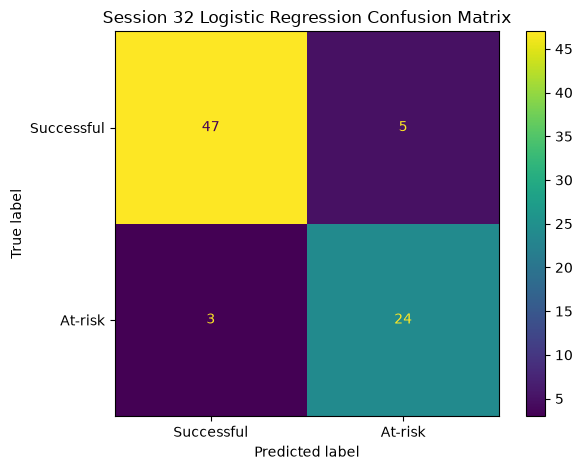

Largest coefficient magnitudes:


,Feature,Coefficient,Absolute_Coefficient,Odds_Ratio,Direction
0,G2,-4.1649,4.1649,0.0155,Toward successful
1,G1,-1.9714,1.9714,0.1393,Toward successful
2,age,0.8799,0.8799,2.4107,Toward at-risk
3,Fjob_other,-0.7745,0.7745,0.4610,Toward successful
4,famrel,-0.6580,0.6580,0.5179,Toward successful
5,Mjob_other,0.4796,0.4796,1.6154,Toward at-risk
6,Fjob_teacher,-0.3926,0.3926,0.6753,Toward successful
7,studytime,0.3837,0.3837,1.4677,Toward at-risk
8,famsize_LE3,0.3804,0.3804,1.4628,Toward at-risk
9,Mjob_teacher,0.3171,0.3171,1.3731,Toward at-risk


In [5]:

logistic_confusion_matrix = confusion_matrix(ycte, y_pred_logistic, labels=[0, 1])
display(pd.DataFrame(
    logistic_confusion_matrix,
    index=["Actual successful", "Actual at-risk"],
    columns=["Predicted successful", "Predicted at-risk"],
))

ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=["Successful", "At-risk"],
).plot(values_format="d")
plt.title("Session 32 Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

fitted_logistic = clf.named_steps["logisticregression"]
logistic_coefficients = pd.DataFrame({
    "Feature": Xtr_f.columns,
    "Coefficient": fitted_logistic.coef_[0],
})
logistic_coefficients["Absolute_Coefficient"] = logistic_coefficients["Coefficient"].abs()
logistic_coefficients["Odds_Ratio"] = np.exp(logistic_coefficients["Coefficient"])
logistic_coefficients["Direction"] = np.select(
    [logistic_coefficients["Coefficient"] > 0, logistic_coefficients["Coefficient"] < 0],
    ["Toward at-risk", "Toward successful"],
    default="No directional effect",
)
logistic_coefficients = logistic_coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False,
).reset_index(drop=True)

print("Largest coefficient magnitudes:")
display(logistic_coefficients.head(20).round(4))


## 6. Classification-table row and final validation

In [6]:

tn, fp, fn, tp = logistic_confusion_matrix.ravel()
classification_row = pd.DataFrame([{
    "Session": 32,
    "Model": "Logistic Regression",
    "Task": "Binary Classification",
    "Scenario": "Full-information",
    "Positive_Class": "At-risk: G3 < 10",
    "Decision_Threshold": 0.50,
    "Accuracy": logistic_metrics["accuracy"],
    "Precision": logistic_metrics["precision"],
    "Recall": logistic_metrics["recall"],
    "F1": logistic_metrics["f1"],
    "ROC_AUC": logistic_metrics["roc_auc"],
    "True_Negative": int(tn),
    "False_Positive": int(fp),
    "False_Negative": int(fn),
    "True_Positive": int(tp),
    "Test_Rows": int(len(ycte)),
}])

print("Session 32 classification-table row:")
display(classification_row.round(4))

assert isinstance(clf.named_steps["standardscaler"], StandardScaler)
assert isinstance(clf.named_steps["logisticregression"], LogisticRegression)
assert clf.named_steps["logisticregression"].max_iter == 1000
assert set(clf.classes_) == {0, 1}
assert len(y_pred_logistic) == len(ycte)
assert len(y_proba_logistic) == len(ycte)
assert np.isfinite(y_proba_logistic).all()
assert ((y_proba_logistic >= 0) & (y_proba_logistic <= 1)).all()
assert len(logistic_coefficients) == Xtr_f.shape[1]
assert classification_row.shape[0] == 1
assert classification_row.loc[0, "Positive_Class"] == "At-risk: G3 < 10"

print("SESSION 32 GITHUB DELIVERABLE COMPLETED SUCCESSFULLY")
print(f"Accuracy: {logistic_metrics['accuracy']:.4f}")
print(f"At-risk recall: {logistic_metrics['recall']:.4f}")
print("Notebook: notebooks/05_classification_models.ipynb")


Session 32 classification-table row:


,Session,Model,Task,Scenario,Positive_Class,Decision_Threshold,Accuracy,Precision,Recall,F1,ROC_AUC,True_Negative,False_Positive,False_Negative,True_Positive,Test_Rows
0,32,Logistic Regression,Binary Classification,Full-information,At-risk: G3 < 10,0.5,0.8987,0.8276,0.8889,0.8571,0.9736,47,5,3,24,79


SESSION 32 GITHUB DELIVERABLE COMPLETED SUCCESSFULLY
Accuracy: 0.8987
At-risk recall: 0.8889
Notebook: notebooks/05_classification_models.ipynb


<!-- SESSION 33 GITHUB DELIVERABLE START -->
# Session 33: KNN, SVM, and Naive Bayes Classification

This section trains three additional classifiers using the same fixed training
and test sets used by the earlier classification models. Scaling is performed
inside each pipeline to prevent data leakage.

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

required_session33_objects = ["Xtr_f", "Xte_f", "yctr", "ycte"]
missing_session33_objects = [
    name for name in required_session33_objects if name not in globals()
]
if missing_session33_objects:
    raise NameError(
        "Run the earlier data-preparation and fixed-split cells first. "
        f"Missing: {missing_session33_objects}"
    )

if len(Xtr_f) != len(yctr) or len(Xte_f) != len(ycte):
    raise AssertionError("Feature and target row counts do not match.")

if len(set(np.asarray(yctr).ravel())) != 2:
    raise AssertionError("Session 33 requires a binary classification target.")

print("Fixed classification split verified.")
print(f"Training rows: {len(Xtr_f):,}")
print(f"Test rows:     {len(Xte_f):,}")

In [ ]:
session33_models = {
    "KNN": (
        "K-Nearest Neighbors",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=5)),
        ]),
    ),
    "SVM": (
        "Support Vector Machine",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, random_state=2026)),
        ]),
    ),
    "NB": (
        "Gaussian Naive Bayes",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB()),
        ]),
    ),
}

session33_rows = []
session33_fitted_models = {}

for short_name, (full_name, pipeline) in session33_models.items():
    pipeline.fit(Xtr_f, np.asarray(yctr).ravel())
    predictions = pipeline.predict(Xte_f)
    probabilities = pipeline.predict_proba(Xte_f)
    classes = list(pipeline.named_steps["model"].classes_)

    # The project defines class 0 as the at-risk class and class 1 as success.
    success_probability = probabilities[:, classes.index(1)]

    row = {
        "Model": short_name,
        "Full_Model_Name": full_name,
        "Scaling_Used": True,
        "accuracy": accuracy_score(ycte, predictions),
        "precision": precision_score(ycte, predictions, pos_label=1, zero_division=0),
        "recall": recall_score(ycte, predictions, pos_label=1, zero_division=0),
        "f1": f1_score(ycte, predictions, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(ycte, success_probability),
        "at_risk_precision": precision_score(ycte, predictions, pos_label=0, zero_division=0),
        "at_risk_recall": recall_score(ycte, predictions, pos_label=0, zero_division=0),
        "at_risk_f1": f1_score(ycte, predictions, pos_label=0, zero_division=0),
    }
    session33_rows.append(row)
    session33_fitted_models[short_name] = pipeline

session33_results_df = (
    pd.DataFrame(session33_rows)
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

display(session33_results_df.style.format({
    "accuracy": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
    "at_risk_precision": "{:.4f}",
    "at_risk_recall": "{:.4f}",
    "at_risk_f1": "{:.4f}",
}))

In [ ]:
classification_metric_columns = [
    "Model",
    "Full_Model_Name",
    "Scaling_Used",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "at_risk_precision",
    "at_risk_recall",
    "at_risk_f1",
]

possible_existing_tables = [
    "classification_table",
    "classification_comparison_df",
    "classification_results_df",
]
existing_classification_table = None

for table_name in possible_existing_tables:
    candidate = globals().get(table_name)
    if isinstance(candidate, pd.DataFrame):
        existing_classification_table = candidate.copy()
        print(f"Existing classification table found: {table_name}")
        break

new_session33_rows = session33_results_df[classification_metric_columns].copy()

if (
    existing_classification_table is None
    or existing_classification_table.empty
    or "Model" not in existing_classification_table.columns
):
    classification_table = new_session33_rows.copy()
else:
    for column_name in classification_metric_columns:
        if column_name not in existing_classification_table.columns:
            existing_classification_table[column_name] = np.nan

    existing_classification_table = existing_classification_table.loc[
        ~existing_classification_table["Model"].isin(["KNN", "SVM", "NB"]),
        classification_metric_columns,
    ].copy()
    classification_table = pd.concat(
        [existing_classification_table, new_session33_rows],
        ignore_index=True,
    )

classification_table = (
    classification_table
    .sort_values("f1", ascending=False, na_position="last")
    .reset_index(drop=True)
)
classification_table.insert(
    0, "Overall_F1_Rank", range(1, len(classification_table) + 1)
)

display(classification_table.style.format({
    column: "{:.4f}"
    for column in [
        "accuracy", "precision", "recall", "f1", "roc_auc",
        "at_risk_precision", "at_risk_recall", "at_risk_f1",
    ]
}))

In [ ]:
current_directory = Path.cwd()
repository_root = next(
    (
        directory
        for directory in [current_directory, *current_directory.parents]
        if (directory / ".git").exists()
    ),
    current_directory,
)
output_directory = repository_root / "reports" / "tables"
output_directory.mkdir(parents=True, exist_ok=True)

session33_rows_path = output_directory / "session33_classification_rows.csv"
classification_table_path = output_directory / "classification_table.csv"

session33_results_df.to_csv(session33_rows_path, index=False)
classification_table.to_csv(classification_table_path, index=False)

print("Session 33 artifact files created:")
print(session33_rows_path)
print(classification_table_path)

In [ ]:
expected_models = {"KNN", "SVM", "NB"}
actual_models = set(session33_results_df["Model"])
required_metrics = [
    "accuracy", "precision", "recall", "f1", "roc_auc",
    "at_risk_precision", "at_risk_recall", "at_risk_f1",
]

if actual_models != expected_models or len(session33_results_df) != 3:
    raise AssertionError("Results must contain exactly one KNN, SVM, and NB row.")
if session33_results_df[required_metrics].isna().any().any():
    raise AssertionError("One or more Session 33 metrics are missing.")

metric_values = session33_results_df[required_metrics].to_numpy(dtype=float)
if not np.isfinite(metric_values).all():
    raise AssertionError("One or more Session 33 metrics are not finite.")
if not ((metric_values >= 0) & (metric_values <= 1)).all():
    raise AssertionError("Classification metrics must be between zero and one.")

rows_in_main_table = classification_table[
    classification_table["Model"].isin(expected_models)
]
if len(rows_in_main_table) != 3:
    raise AssertionError("The classification table is missing a Session 33 row.")

best_row = session33_results_df.iloc[0]
print("=" * 72)
print("SESSION 33 GITHUB DELIVERABLE COMPLETED SUCCESSFULLY")
print("=" * 72)
print(f"Highest-F1 Session 33 classifier: {best_row['Full_Model_Name']}")
print(f"Highest Session 33 F1: {best_row['f1']:.4f}")

### Session 33 interpretation

- **KNN** assumes that nearby observations in the scaled feature space tend to
  share the same class.
- **SVM** searches for a maximum-margin boundary between the classes.
- **Gaussian Naive Bayes** assumes that predictors are conditionally
  independent given the class label and approximately Gaussian within each
  class.

The Naive Bayes independence assumption is unlikely to be fully realistic for
student-performance data. Prior grades, failures, study time, absences, and
support can remain related even within the same outcome class. Naive Bayes is
nevertheless useful as a fast, interpretable baseline.

<!-- SESSION 33 GITHUB DELIVERABLE END -->

# Session 34: Decision Tree Classification

This section trains an interpretable, depth-limited Decision Tree classifier on the same held-out split used by the earlier classification models. Class `0` means **at risk** and class `1` means **successful**.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

required_s34 = ["Xtr_f", "Xte_f", "yctr", "ycte", "eval_clf"]
missing_s34 = [name for name in required_s34 if name not in globals()]
if missing_s34:
    raise NameError(
        "Run the earlier classification cells first. Missing objects: "
        + ", ".join(missing_s34)
    )

yctr_s34 = np.asarray(yctr).ravel()
ycte_s34 = np.asarray(ycte).ravel()
assert Xtr_f.shape[0] == len(yctr_s34)
assert Xte_f.shape[0] == len(ycte_s34)

dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
dtc.fit(Xtr_f, yctr_s34)
dtc_predictions = dtc.predict(Xte_f)
dtc_metrics = eval_clf(ycte_s34, dtc_predictions)

at_risk_metrics = {
    "at_risk_precision": precision_score(ycte_s34, dtc_predictions, pos_label=0, zero_division=0),
    "at_risk_recall": recall_score(ycte_s34, dtc_predictions, pos_label=0, zero_division=0),
    "at_risk_f1": f1_score(ycte_s34, dtc_predictions, pos_label=0, zero_division=0),
}

print("Decision Tree metrics:", dtc_metrics)
print("At-risk metrics:", at_risk_metrics)
print("Actual depth:", dtc.get_depth())
print("Leaves:", dtc.get_n_leaves())
print(classification_report(
    ycte_s34, dtc_predictions,
    labels=[0, 1], target_names=["At risk", "Successful"],
    digits=4, zero_division=0,
))

ConfusionMatrixDisplay.from_predictions(
    ycte_s34, dtc_predictions,
    labels=[0, 1], display_labels=["At risk", "Successful"],
    values_format="d",
)
plt.title("Session 34: Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()


In [ ]:
feature_count_s34 = Xtr_f.shape[1]
if hasattr(Xtr_f, "columns"):
    feature_names_s34 = [str(name) for name in Xtr_f.columns]
elif "X_full" in globals() and hasattr(X_full, "columns") and X_full.shape[1] == feature_count_s34:
    feature_names_s34 = [str(name) for name in X_full.columns]
else:
    feature_names_s34 = [f"feature_{index}" for index in range(feature_count_s34)]

tree_class_names = ["At risk" if int(value) == 0 else "Successful" for value in dtc.classes_]
plt.figure(figsize=(26, 14))
plot_tree(
    dtc,
    feature_names=feature_names_s34,
    class_names=tree_class_names,
    max_depth=3,
    filled=True,
    rounded=True,
    proportion=True,
    precision=2,
    fontsize=8,
)
plt.title("Session 34 Decision Tree Classifier - Top Three Levels")
plt.tight_layout()
plt.show()

tree_rules_s34 = export_text(
    dtc, feature_names=feature_names_s34, max_depth=3, decimals=2
)
print("Top Decision Tree rules:\n")
print(tree_rules_s34)

feature_importance_s34 = (
    pd.DataFrame({"Feature": feature_names_s34, "Importance": dtc.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance_s34.head(15))


In [ ]:
def metric_s34(metrics, name):
    for key in (name, name.lower(), name.upper(), name.capitalize()):
        if key in metrics:
            return float(metrics[key])
    raise KeyError(f"eval_clf output does not contain {name!r}: {list(metrics)}")

tree_classifier_row = pd.DataFrame([{
    "Model": "Decision Tree",
    "Accuracy": metric_s34(dtc_metrics, "accuracy"),
    "Precision": metric_s34(dtc_metrics, "precision"),
    "Recall": metric_s34(dtc_metrics, "recall"),
    "F1": metric_s34(dtc_metrics, "f1"),
}])

existing_table_s34 = None
for table_name_s34 in (
    "classification_table",
    "classification_results",
    "classification_leaderboard",
    "clf_table",
):
    candidate_s34 = globals().get(table_name_s34)
    if isinstance(candidate_s34, pd.DataFrame):
        existing_table_s34 = candidate_s34.copy()
        break

if existing_table_s34 is None:
    classification_table = tree_classifier_row.copy()
else:
    rename_s34 = {
        column: str(column).strip().capitalize()
        for column in existing_table_s34.columns
        if str(column).strip().lower() in {"model", "accuracy", "precision", "recall", "f1"}
    }
    classification_table = existing_table_s34.rename(columns=rename_s34)
    for column_s34 in ["Model", "Accuracy", "Precision", "Recall", "F1"]:
        if column_s34 not in classification_table.columns:
            classification_table[column_s34] = np.nan
    classification_table = classification_table[
        classification_table["Model"].astype(str).str.strip().str.lower() != "decision tree"
    ].copy()
    classification_table = pd.concat(
        [classification_table, tree_classifier_row], ignore_index=True
    )

output_directory_s34 = os.path.join("results", "session34")
os.makedirs(output_directory_s34, exist_ok=True)
classification_output_s34 = os.path.join(
    output_directory_s34, "session34_classification_table.csv"
)
tree_output_s34 = os.path.join(
    output_directory_s34, "session34_decision_tree_row.csv"
)
classification_table.to_csv(classification_output_s34, index=False)
tree_classifier_row.to_csv(tree_output_s34, index=False)

decision_tree_rows_s34 = classification_table[
    classification_table["Model"].astype(str).str.strip().str.lower() == "decision tree"
]
assert dtc.max_depth == 5
assert dtc.random_state == 42
assert dtc.get_depth() <= 5
assert len(dtc_predictions) == len(ycte_s34)
assert set(np.unique(dtc_predictions)).issubset({0, 1})
assert len(decision_tree_rows_s34) == 1
assert list(tree_classifier_row.columns) == ["Model", "Accuracy", "Precision", "Recall", "F1"]
assert tree_classifier_row[["Accuracy", "Precision", "Recall", "F1"]].notna().all().all()

display(classification_table)
print("Saved:", classification_output_s34)
print("Saved:", tree_output_s34)
print("SESSION 34 NOTEBOOK SECTION COMPLETED SUCCESSFULLY")


## Responsible-use reflection

A teacher should use a readable rule only as an early-warning screening aid, not as an automatic judgment. The teacher should verify the underlying information, speak with the student, consider circumstances absent from the data, protect confidentiality, check for errors and bias, and use the result to offer support rather than punishment or labeling. The rule shows an association, not proof of cause or certainty about an individual student.


## Session 35: Random Forest Classification

This section trains a 300-tree Random Forest classifier and compares it with the single Decision Tree on the same held-out test set.

- Class `0` = at-risk student
- Class `1` = successful student
- Primary safety-oriented metric = at-risk recall (`pos_label=0`)
- Complementary discrimination metric = ROC AUC

The test set is used only for final evaluation, not for model selection or tuning.

In [ ]:
# Session 35 - imports, prerequisite validation, and Random Forest training
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

required_objects = ["Xtr_f", "Xte_f", "yctr", "ycte"]
missing_objects = [name for name in required_objects if name not in globals()]
if missing_objects:
    raise NameError(
        "Run the earlier classification data-preparation cells first. "
        f"Missing objects: {missing_objects}"
    )

# Preserve a Session 35-specific reference to the held-out labels.
ycte_s35 = ycte

rfc = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)
rfc.fit(Xtr_f, yctr)

forest_predictions = rfc.predict(Xte_f)
forest_success_probability = rfc.predict_proba(Xte_f)[:, 1]
forest_at_risk_probability = rfc.predict_proba(Xte_f)[:, 0]

print("SESSION 35 RANDOM FOREST TRAINING PASSED")


In [ ]:
# Session 35 - model evaluation, Decision Tree comparison, confusion matrix, and ROC curve
if "eval_clf" in globals() and callable(eval_clf):
    print("Existing eval_clf output:")
    print(eval_clf(ycte_s35, forest_predictions, forest_success_probability))

rf_accuracy = accuracy_score(ycte_s35, forest_predictions)
rf_success_precision = precision_score(ycte_s35, forest_predictions, pos_label=1, zero_division=0)
rf_success_recall = recall_score(ycte_s35, forest_predictions, pos_label=1, zero_division=0)
rf_success_f1 = f1_score(ycte_s35, forest_predictions, pos_label=1, zero_division=0)
rf_roc_auc = roc_auc_score(ycte_s35, forest_success_probability)
rf_at_risk_precision = precision_score(ycte_s35, forest_predictions, pos_label=0, zero_division=0)
rf_at_risk_recall = recall_score(ycte_s35, forest_predictions, pos_label=0, zero_division=0)
rf_at_risk_f1 = f1_score(ycte_s35, forest_predictions, pos_label=0, zero_division=0)
rf_at_risk_auc = roc_auc_score(
    (np.asarray(ycte_s35) == 0).astype(int),
    forest_at_risk_probability,
)

tree_at_risk_recall = None
if "tree_classifier_row" in globals():
    for key in ("Recall_At_Risk", "At-Risk Recall", "At_Risk_Recall"):
        if key in tree_classifier_row:
            tree_at_risk_recall = float(tree_classifier_row[key])
            break
if tree_at_risk_recall is None:
    for prediction_name in ("tree_predictions", "dt_predictions", "dtc_predictions", "y_pred_tree"):
        if prediction_name in globals():
            tree_at_risk_recall = recall_score(
                ycte_s35,
                globals()[prediction_name],
                pos_label=0,
                zero_division=0,
            )
            break
if tree_at_risk_recall is None:
    raise NameError(
        "A Decision Tree result is required for the recall comparison. "
        "Run the Session 34 Decision Tree cells first."
    )

recall_change = rf_at_risk_recall - tree_at_risk_recall
recall_comparison = pd.DataFrame(
    {
        "Model": ["Decision Tree", "Random Forest"],
        "Recall_At_Risk": [tree_at_risk_recall, rf_at_risk_recall],
    }
)
recall_comparison["Difference_From_Tree"] = [0.0, recall_change]

print("Random Forest Classification Metrics")
print("------------------------------------")
print(f"Accuracy:          {rf_accuracy:.4f}")
print(f"At-risk precision: {rf_at_risk_precision:.4f}")
print(f"At-risk recall:    {rf_at_risk_recall:.4f}")
print(f"At-risk F1:        {rf_at_risk_f1:.4f}")
print(f"ROC AUC:           {rf_roc_auc:.4f}")
print(f"Tree recall:       {tree_at_risk_recall:.4f}")
print(f"Recall change:     {recall_change:+.4f}")
display(recall_comparison)

session35_figure_dir = Path("results/session35")
session35_figure_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    ycte_s35,
    forest_predictions,
    display_labels=["At risk", "Successful"],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)
ax.set_title("Session 35 Random Forest Confusion Matrix")
fig.tight_layout()
fig.savefig(session35_figure_dir / "session35_random_forest_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
RocCurveDisplay.from_predictions(
    (np.asarray(ycte_s35) == 0).astype(int),
    forest_at_risk_probability,
    name="Random Forest (at risk)",
    ax=ax,
)
ax.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
ax.set_title("Session 35 At-Risk ROC Curve")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(session35_figure_dir / "session35_random_forest_at_risk_roc.png", dpi=200, bbox_inches="tight")
plt.show()


In [ ]:
# Session 35 - add exactly one Random Forest row to the classification table
random_forest_row = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision_Success": rf_success_precision,
    "Recall_Success": rf_success_recall,
    "F1_Success": rf_success_f1,
    "ROC_AUC": rf_roc_auc,
    "Precision_At_Risk": rf_at_risk_precision,
    "Recall_At_Risk": rf_at_risk_recall,
    "F1_At_Risk": rf_at_risk_f1,
    "ROC_AUC_At_Risk": rf_at_risk_auc,
}
random_forest_row_df = pd.DataFrame([random_forest_row])

if "classification_table" not in globals() or not isinstance(classification_table, pd.DataFrame):
    classification_table = pd.DataFrame(columns=random_forest_row_df.columns)

classification_table = classification_table.copy()
for column in random_forest_row_df.columns:
    if column not in classification_table.columns:
        classification_table[column] = np.nan
for column in classification_table.columns:
    if column not in random_forest_row_df.columns:
        random_forest_row_df[column] = np.nan

random_forest_row_df = random_forest_row_df[classification_table.columns]
classification_table = classification_table[
    classification_table["Model"].astype(str).str.strip().str.lower().ne("random forest")
].copy()
classification_table = pd.concat(
    [classification_table, random_forest_row_df],
    ignore_index=True,
)

random_forest_rows = classification_table[
    classification_table["Model"].astype(str).str.strip().str.lower().eq("random forest")
]
assert len(random_forest_rows) == 1, "The table must contain exactly one Random Forest row."

display(classification_table)
print("RANDOM FOREST CLASSIFICATION ROW PASSED")


In [ ]:
# Session 35 - save and verify reproducible output artifacts
SESSION35_OUTPUT_DIR = Path("results/session35")
SESSION35_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

classification_table_path = SESSION35_OUTPUT_DIR / "session35_classification_table.csv"
random_forest_row_path = SESSION35_OUTPUT_DIR / "session35_random_forest_row.csv"
recall_comparison_path = SESSION35_OUTPUT_DIR / "session35_recall_comparison.csv"

classification_table.to_csv(classification_table_path, index=False)
random_forest_row_df.to_csv(random_forest_row_path, index=False)
recall_comparison.to_csv(recall_comparison_path, index=False)

required_columns = [
    "Model", "Accuracy", "Precision_Success", "Recall_Success", "F1_Success",
    "ROC_AUC", "Precision_At_Risk", "Recall_At_Risk", "F1_At_Risk",
    "ROC_AUC_At_Risk",
]
missing_columns = [column for column in required_columns if column not in random_forest_row_df.columns]
assert not missing_columns, f"Missing Random Forest columns: {missing_columns}"
assert len(random_forest_row_df) == 1
assert random_forest_row_df.iloc[0]["Model"] == "Random Forest"

metric_values = random_forest_row_df[required_columns[1:]].to_numpy(dtype=float)
assert np.isfinite(metric_values).all()
assert ((metric_values >= 0) & (metric_values <= 1)).all()
assert classification_table_path.exists()
assert random_forest_row_path.exists()
assert recall_comparison_path.exists()

print("SESSION 35 OUTPUT ARTIFACT PASSED")
print("Saved:", classification_table_path)
print("Saved:", random_forest_row_path)
print("Saved:", recall_comparison_path)


### Session 35 Reflection: Why use ROC AUC with accuracy?

ROC AUC complements accuracy because accuracy reports correctness at one selected classification cutoff and can appear high when successful students greatly outnumber at-risk students. A model could predict the majority class for nearly everyone and still attain high accuracy while missing students who may need support. ROC AUC instead measures how well the model ranks or separates the two classes across all possible thresholds. It should therefore be interpreted together with at-risk recall and precision: recall shows how many truly at-risk students are detected, while precision indicates how many alerts correspond to genuinely at-risk students. These measures support intervention planning; they do not justify surveillance, labeling, or causal claims.

# Session 36: Gradient Boosting and AdaBoost

This section trains both boosting classifiers on the existing fixed classification
split, evaluates at-risk detection, and adds both rows to the classification leaderboard.

In [ ]:
# SESSION_36_BOOSTING_GITHUB_DELIVERABLE
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

required_s36 = ["Xtr_f", "Xte_f", "yctr", "ycte"]
missing_s36 = [name for name in required_s36 if name not in globals()]
if missing_s36:
    raise NameError(
        "Run the earlier classification preparation cells first. Missing: "
        + ", ".join(missing_s36)
    )

y_train_s36 = np.asarray(yctr).ravel()
y_test_s36 = np.asarray(ycte).ravel()

if Xtr_f.shape[0] != len(y_train_s36):
    raise ValueError("Xtr_f and yctr have different row counts.")
if Xte_f.shape[0] != len(y_test_s36):
    raise ValueError("Xte_f and ycte have different row counts.")

labels_s36 = np.unique(np.concatenate([y_train_s36, y_test_s36]))
if len(labels_s36) != 2:
    raise ValueError(f"Session 36 requires binary labels; detected {labels_s36}.")

AT_RISK_LABEL_S36 = 1 if 1 in labels_s36 else labels_s36[-1]
print("Session 36 inputs verified.")
print("Training shape:", Xtr_f.shape)
print("Testing shape: ", Xte_f.shape)
print("At-risk label: ", AT_RISK_LABEL_S36)

In [ ]:
# Train and evaluate Gradient Boosting and AdaBoost.
boosting_models_s36 = {
    "GradBoost": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
}

boosting_records_s36 = []
fitted_boosting_models_s36 = {}

for model_name, estimator in boosting_models_s36.items():
    start = time.perf_counter()
    estimator.fit(Xtr_f, y_train_s36)
    fit_seconds = time.perf_counter() - start

    predictions = estimator.predict(Xte_f)
    class_index = list(estimator.classes_).index(AT_RISK_LABEL_S36)
    probabilities = estimator.predict_proba(Xte_f)[:, class_index]
    binary_actual = (y_test_s36 == AT_RISK_LABEL_S36).astype(int)

    boosting_records_s36.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_s36, predictions),
        "Precision": precision_score(
            y_test_s36, predictions, pos_label=AT_RISK_LABEL_S36, zero_division=0
        ),
        "Recall": recall_score(
            y_test_s36, predictions, pos_label=AT_RISK_LABEL_S36, zero_division=0
        ),
        "F1": f1_score(
            y_test_s36, predictions, pos_label=AT_RISK_LABEL_S36, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(binary_actual, probabilities),
        "Fit_Time_Seconds": fit_seconds,
    })
    fitted_boosting_models_s36[model_name] = estimator

boosting_results_s36 = (
    pd.DataFrame(boosting_records_s36)
    .sort_values(["F1", "Recall", "ROC_AUC", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)
boosting_results_s36.insert(0, "Boosting_Rank", range(1, len(boosting_results_s36) + 1))
display(boosting_results_s36.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
    "F1": "{:.4f}", "ROC_AUC": "{:.4f}", "Fit_Time_Seconds": "{:.4f}",
}))

In [ ]:
# Add both Session 36 models to the project classification leaderboard.
session36_rows = boosting_results_s36[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].copy()
session36_rows["Model_Family"] = "Boosting Ensemble"
session36_rows["Session"] = 36

columns_s36 = [
    "Model", "Model_Family", "Session", "Accuracy", "Precision",
    "Recall", "F1", "ROC_AUC",
]

existing_s36 = None
for variable_name in [
    "classification_leaderboard", "classification_table",
    "clf_leaderboard", "model_comparison_classification",
]:
    candidate = globals().get(variable_name)
    if isinstance(candidate, pd.DataFrame):
        existing_s36 = candidate.copy()
        break

if existing_s36 is None:
    existing_s36 = pd.DataFrame(columns=columns_s36)

rename_s36 = {
    "model": "Model", "model_name": "Model", "accuracy": "Accuracy",
    "precision": "Precision", "recall": "Recall", "f1": "F1",
    "f1_score": "F1", "roc_auc": "ROC_AUC", "auc": "ROC_AUC",
}
for old_column in list(existing_s36.columns):
    normalized = str(old_column).strip().lower().replace(" ", "_")
    new_column = rename_s36.get(normalized)
    if new_column and new_column not in existing_s36.columns:
        existing_s36 = existing_s36.rename(columns={old_column: new_column})

for column in columns_s36:
    if column not in existing_s36.columns:
        if column == "Model_Family":
            existing_s36[column] = "Earlier Classifier"
        elif column == "Session":
            existing_s36[column] = pd.NA
        else:
            existing_s36[column] = np.nan

# Idempotency: remove prior boosting rows before adding current results.
existing_s36 = existing_s36[columns_s36]
existing_s36 = existing_s36[
    ~existing_s36["Model"].isin(["GradBoost", "AdaBoost"])
].copy()

classification_leaderboard = pd.concat(
    [existing_s36, session36_rows[columns_s36]], ignore_index=True
)
for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]:
    classification_leaderboard[metric] = pd.to_numeric(
        classification_leaderboard[metric], errors="coerce"
    )

classification_leaderboard = (
    classification_leaderboard
    .sort_values(
        ["F1", "Recall", "ROC_AUC", "Accuracy", "Precision"],
        ascending=False,
        na_position="last",
    )
    .reset_index(drop=True)
)
classification_leaderboard.insert(
    0, "Rank", range(1, len(classification_leaderboard) + 1)
)

output_dir_s36 = Path("reports") / "tables"
output_dir_s36.mkdir(parents=True, exist_ok=True)
classification_leaderboard.to_csv(
    output_dir_s36 / "classification_leaderboard.csv", index=False
)
display(classification_leaderboard)

In [ ]:
# Final Session 36 verification.
assert set(boosting_results_s36["Model"]) == {"GradBoost", "AdaBoost"}
assert len(boosting_results_s36) == 2
assert classification_leaderboard["Model"].eq("GradBoost").sum() == 1
assert classification_leaderboard["Model"].eq("AdaBoost").sum() == 1
assert not boosting_results_s36[
    ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
].isna().any().any()

print("=" * 70)
print("SESSION 36 NOTEBOOK DELIVERABLE COMPLETED")
print("Gradient Boosting and AdaBoost are in the classification leaderboard.")
print("=" * 70)

<!-- SESSION 37 AUTOMATION CELL -->
# Session 37: Neural-Network Classification

This section trains a scaled multilayer perceptron (MLP) classifier using the existing classification split. It adds exactly one **MLP Classifier** row to the classification leaderboard, compares the MLP with the boosting models, and evaluates stability across five random seeds.

Project class definitions: **0 = at risk** and **1 = successful**.

In [ ]:
# SESSION 37 AUTOMATION CELL - imports and prerequisite checks
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

required_objects_s37 = ["Xtr_f", "Xte_f", "yctr", "ycte"]
missing_objects_s37 = [name for name in required_objects_s37 if name not in globals()]
if missing_objects_s37:
    raise NameError(
        "Run the earlier classification cells first. Missing objects: "
        + ", ".join(missing_objects_s37)
    )

yctr_s37 = np.asarray(yctr).ravel()
ycte_s37 = np.asarray(ycte).ravel()
if Xtr_f.shape[0] != len(yctr_s37) or Xte_f.shape[0] != len(ycte_s37):
    raise ValueError("Feature and target row counts do not match.")

observed_classes_s37 = set(np.unique(np.concatenate([yctr_s37, ycte_s37])))
if observed_classes_s37 != {0, 1}:
    raise ValueError(f"Expected binary labels 0 and 1; found {sorted(observed_classes_s37)}")
if len(np.unique(ycte_s37)) != 2:
    raise ValueError("The test set must contain both classes for ROC AUC.")

print("Session 37 prerequisites verified.")
print("Training shape:", Xtr_f.shape, "Test shape:", Xte_f.shape)

In [ ]:
# SESSION 37 AUTOMATION CELL - train and evaluate the required MLP
mlpc = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=1000,
        random_state=42,
    ),
)

with warnings.catch_warnings(record=True) as mlp_warning_records_s37:
    warnings.simplefilter("always", ConvergenceWarning)
    mlp_fit_start_s37 = time.perf_counter()
    mlpc.fit(Xtr_f, yctr_s37)
    mlp_fit_time_s37 = time.perf_counter() - mlp_fit_start_s37

mlp_model_s37 = mlpc.named_steps["mlpclassifier"]
mlp_convergence_warnings_s37 = sum(
    issubclass(item.category, ConvergenceWarning)
    for item in mlp_warning_records_s37
)
mlp_train_predictions_s37 = mlpc.predict(Xtr_f)
mlp_predictions_s37 = mlpc.predict(Xte_f)

class_positions_s37 = np.where(mlp_model_s37.classes_ == 0)[0]
if len(class_positions_s37) != 1:
    raise ValueError("The fitted MLP does not contain at-risk class 0.")
mlp_at_risk_probability_s37 = mlpc.predict_proba(Xte_f)[:, int(class_positions_s37[0])]

mlp_accuracy_s37 = accuracy_score(ycte_s37, mlp_predictions_s37)
mlp_precision_s37 = precision_score(ycte_s37, mlp_predictions_s37, pos_label=1, zero_division=0)
mlp_recall_s37 = recall_score(ycte_s37, mlp_predictions_s37, pos_label=1, zero_division=0)
mlp_f1_s37 = f1_score(ycte_s37, mlp_predictions_s37, pos_label=1, zero_division=0)
mlp_roc_auc_s37 = roc_auc_score((ycte_s37 == 0).astype(int), mlp_at_risk_probability_s37)
mlp_at_risk_precision_s37 = precision_score(ycte_s37, mlp_predictions_s37, pos_label=0, zero_division=0)
mlp_at_risk_recall_s37 = recall_score(ycte_s37, mlp_predictions_s37, pos_label=0, zero_division=0)
mlp_at_risk_f1_s37 = f1_score(ycte_s37, mlp_predictions_s37, pos_label=0, zero_division=0)

if "eval_clf" in globals():
    print("Project eval_clf result:", eval_clf(ycte_s37, mlp_predictions_s37))

mlp_row_s37 = pd.DataFrame([{
    "Model": "MLP Classifier",
    "Accuracy": mlp_accuracy_s37,
    "Precision": mlp_precision_s37,
    "Recall": mlp_recall_s37,
    "F1": mlp_f1_s37,
    "ROC AUC": mlp_roc_auc_s37,
    "At-Risk Precision": mlp_at_risk_precision_s37,
    "At-Risk Recall": mlp_at_risk_recall_s37,
    "At-Risk F1": mlp_at_risk_f1_s37,
    "Fit Time Seconds": mlp_fit_time_s37,
}])
display(mlp_row_s37.round(4))

In [ ]:
# SESSION 37 AUTOMATION CELL - update and rank the classification leaderboard
if "classification_table" in globals():
    existing_classification_table_s37 = classification_table.copy()
elif "classification_leaderboard" in globals():
    existing_classification_table_s37 = classification_leaderboard.copy()
elif "classification_leaderboard_s36" in globals():
    existing_classification_table_s37 = classification_leaderboard_s36.copy()
elif "boosting_results_s36" in globals():
    existing_classification_table_s37 = boosting_results_s36.copy()
else:
    existing_classification_table_s37 = pd.DataFrame()

existing_classification_table_s37 = existing_classification_table_s37.rename(columns={
    "model": "Model", "Model Name": "Model", "accuracy": "Accuracy",
    "precision": "Precision", "recall": "Recall", "f1": "F1",
    "f1_score": "F1", "F1 Score": "F1", "roc_auc": "ROC AUC",
    "ROC_AUC": "ROC AUC", "AUC": "ROC AUC",
})
if "Rank" in existing_classification_table_s37.columns:
    existing_classification_table_s37 = existing_classification_table_s37.drop(columns="Rank")
if "Model" not in existing_classification_table_s37.columns:
    existing_classification_table_s37["Model"] = pd.Series(dtype=str)

existing_classification_table_s37 = existing_classification_table_s37[
    ~existing_classification_table_s37["Model"].astype(str).str.strip().str.lower().isin(
        ["mlp", "mlp classifier", "neural network", "neural-network classifier"]
    )
].copy()

all_columns_s37 = list(dict.fromkeys(
    list(existing_classification_table_s37.columns) + list(mlp_row_s37.columns)
))
for column_s37 in all_columns_s37:
    if column_s37 not in existing_classification_table_s37.columns:
        existing_classification_table_s37[column_s37] = np.nan
    if column_s37 not in mlp_row_s37.columns:
        mlp_row_s37[column_s37] = np.nan

classification_table_s37 = pd.concat(
    [existing_classification_table_s37[all_columns_s37], mlp_row_s37[all_columns_s37]],
    ignore_index=True,
)
sort_columns_s37 = [column for column in ["F1", "Recall", "ROC AUC", "Accuracy"]
                      if column in classification_table_s37.columns]
if sort_columns_s37:
    classification_table_s37 = classification_table_s37.sort_values(
        sort_columns_s37, ascending=False, na_position="last"
    ).reset_index(drop=True)
classification_table_s37.insert(0, "Rank", range(1, len(classification_table_s37) + 1))

classification_table = classification_table_s37.copy()
classification_leaderboard = classification_table_s37.copy()
classification_leaderboard_s37 = classification_table_s37.copy()
display(classification_table_s37.round(4))

In [ ]:
# SESSION 37 AUTOMATION CELL - compare MLP with boosting models
boosting_mask_s37 = classification_table_s37["Model"].astype(str).str.contains(
    "gradient boost|adaboost|ada boost", case=False, regex=True, na=False
)
mlp_mask_s37 = classification_table_s37["Model"].astype(str).str.strip().str.lower().eq(
    "mlp classifier"
)
mlp_vs_boosting_s37 = classification_table_s37[boosting_mask_s37 | mlp_mask_s37].copy()
display(mlp_vs_boosting_s37.round(4))

mlp_train_f1_s37 = f1_score(yctr_s37, mlp_train_predictions_s37, pos_label=0, zero_division=0)
mlp_test_f1_gap_s37 = mlp_train_f1_s37 - mlp_at_risk_f1_s37
print("MLP at-risk training F1:", round(mlp_train_f1_s37, 4))
print("MLP at-risk test F1:", round(mlp_at_risk_f1_s37, 4))
print("Training-minus-test at-risk F1 gap:", round(mlp_test_f1_gap_s37, 4))

In [ ]:
# SESSION 37 AUTOMATION CELL - random-seed stability analysis
stability_rows_s37 = []
for seed_s37 in [7, 21, 42, 99, 2026]:
    candidate_s37 = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=seed_s37),
    )
    with warnings.catch_warnings(record=True) as seed_warnings_s37:
        warnings.simplefilter("always", ConvergenceWarning)
        candidate_s37.fit(Xtr_f, yctr_s37)
    candidate_predictions_s37 = candidate_s37.predict(Xte_f)
    fitted_candidate_s37 = candidate_s37.named_steps["mlpclassifier"]
    stability_rows_s37.append({
        "Random Seed": seed_s37,
        "Accuracy": accuracy_score(ycte_s37, candidate_predictions_s37),
        "F1": f1_score(ycte_s37, candidate_predictions_s37, pos_label=1, zero_division=0),
        "At-Risk Recall": recall_score(ycte_s37, candidate_predictions_s37, pos_label=0, zero_division=0),
        "At-Risk F1": f1_score(ycte_s37, candidate_predictions_s37, pos_label=0, zero_division=0),
        "Iterations": fitted_candidate_s37.n_iter_,
        "Final Loss": float(fitted_candidate_s37.loss_),
        "Convergence Warnings": sum(
            issubclass(item.category, ConvergenceWarning) for item in seed_warnings_s37
        ),
    })

mlp_seed_stability_s37 = pd.DataFrame(stability_rows_s37)
display(mlp_seed_stability_s37.round(4))
print("Mean at-risk F1:", round(mlp_seed_stability_s37["At-Risk F1"].mean(), 4))
print("At-risk F1 standard deviation:", round(mlp_seed_stability_s37["At-Risk F1"].std(ddof=0), 4))
print("At-risk F1 range:", round(mlp_seed_stability_s37["At-Risk F1"].max() - mlp_seed_stability_s37["At-Risk F1"].min(), 4))

<!-- SESSION 37 AUTOMATION CELL -->
### Session 37 reflection

A neural network may be overfitting a small dataset when its training scores are substantially higher than its validation or test scores, training loss continues to fall while validation loss rises, or results change markedly across random seeds and cross-validation folds. Other warning signs include highly confident incorrect predictions, a large training-test F1 gap, convergence instability, and poorer unseen-data performance than simpler models such as logistic regression or boosting. These signs indicate that the network may be learning sample-specific noise rather than patterns that generalize to new students.

In [ ]:
# SESSION 37 AUTOMATION CELL - save and verify all output artifacts
results_dir_s37 = Path("results") / "session37"
results_dir_s37.mkdir(parents=True, exist_ok=True)

classification_table_path_s37 = results_dir_s37 / "session37_classification_table.csv"
mlp_row_path_s37 = results_dir_s37 / "session37_mlp_row.csv"
comparison_path_s37 = results_dir_s37 / "session37_mlp_vs_boosting.csv"
stability_path_s37 = results_dir_s37 / "session37_mlp_seed_stability.csv"

classification_table_s37.to_csv(classification_table_path_s37, index=False)
mlp_row_s37.to_csv(mlp_row_path_s37, index=False)
mlp_vs_boosting_s37.to_csv(comparison_path_s37, index=False)
mlp_seed_stability_s37.to_csv(stability_path_s37, index=False)

mlp_rows_s37 = classification_table_s37[
    classification_table_s37["Model"].astype(str).str.strip().str.lower().eq("mlp classifier")
]
if len(mlp_rows_s37) != 1:
    raise AssertionError(f"Expected exactly one MLP Classifier row; found {len(mlp_rows_s37)}")

required_metrics_s37 = [
    "Accuracy", "Precision", "Recall", "F1", "ROC AUC",
    "At-Risk Precision", "At-Risk Recall", "At-Risk F1",
]
values_s37 = mlp_rows_s37[required_metrics_s37].apply(pd.to_numeric, errors="coerce").to_numpy()
if not np.isfinite(values_s37).all() or not ((values_s37 >= 0) & (values_s37 <= 1)).all():
    raise AssertionError("The MLP row contains missing or invalid metrics.")

print("SESSION 37 OUTPUT ARTIFACT VERIFIED")
print("MLP at-risk F1:", round(mlp_at_risk_f1_s37, 4))
print("MLP ROC AUC:", round(mlp_roc_auc_s37, 4))
print("Convergence warnings:", mlp_convergence_warnings_s37)
print("Classification table path:", classification_table_path_s37)
print("MLP row path:", mlp_row_path_s37)
print("Boosting comparison path:", comparison_path_s37)
print("Seed stability path:", stability_path_s37)